In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.cluster import KMeans

import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [8]:
base_path = "C:/Users/Student/Downloads/Brain Cancer -  MRI dataset"

classes = ["brain_tumor", "brain_menin", "brain_glioma"]

img_size = (512, 512)

images = []
file_names = []
image_ids = []
labels = []

for cls in classes:
    folder_path = f"{base_path}/{cls}"

    for fname in os.listdir(folder_path):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):

            img_path = os.path.join(folder_path, fname)

            img = image.load_img(img_path, target_size=img_size)
            img_array = image.img_to_array(img)

            images.append(img_array)
            file_names.append((cls, fname))
            labels.append(cls)

            match = re.findall(r'(\d{3})', fname)
            if match:
                image_ids.append(f"{cls}_{match[0]}")
            else:
                image_ids.append(f"{cls}_{fname}")

images = np.array(images, dtype="float32")

print("Loaded images:", images.shape)

Loaded images: (6012, 512, 512, 3)


In [9]:
images = preprocess_input(images)

In [10]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

features = base_model.predict(images, batch_size=16, verbose=1)

print("Feature shape:", features.shape)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
376/376 ━━━━━━━━━━━━━━━━━━━━ 741s 2s/step
Feature shape: (6012, 2048)


In [11]:
np.save("features.npy", features)
np.save("file_names.npy", file_names)
np.save("image_ids.npy", image_ids)

In [12]:
features = np.load("features.npy")
file_names = np.load("file_names.npy", allow_pickle=True)
image_ids = np.load("image_ids.npy", allow_pickle=True)

In [13]:
unique_ids = list(dict.fromkeys(image_ids))

grouped_features = []

for uid in unique_ids:
    idxs = [i for i, x in enumerate(image_ids) if x == uid]

    group_feats = features[idxs]
    mean_feat = np.mean(group_feats, axis=0)

    grouped_features.append(mean_feat)

grouped_features = np.array(grouped_features)

print("Grouped feature shape:", grouped_features.shape)

Grouped feature shape: (603, 2048)


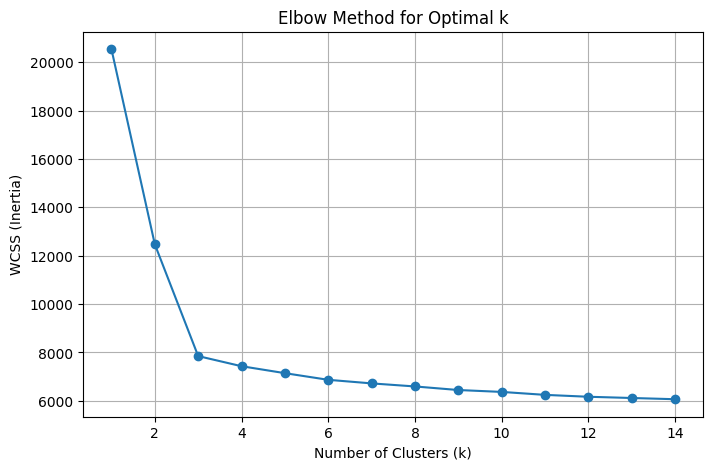

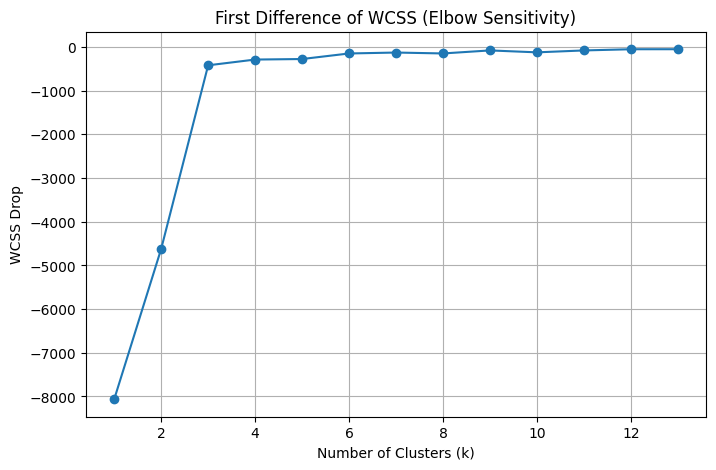

In [14]:
wcss = []

k_values = range(1, 15)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(grouped_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

wcss = np.array(wcss)

diff = np.diff(wcss)

plt.figure(figsize=(8, 5))
plt.plot(k_values[:-1], diff, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS Drop")
plt.title("First Difference of WCSS (Elbow Sensitivity)")
plt.grid(True)
plt.show()

In [ ]:
k = 3 # WHICH IS AMAZING CAUSE ELBOW SUGGESTS 3 CLUSTERS AS WELL YASSSSSSSSSSS

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(grouped_features)
labels = np.array(labels).reshape(-1) # this is the same thing as .flatten() btw, we just need this to become a one dimensional array in order for us to display it

(603,)



Cluster 1 (201)


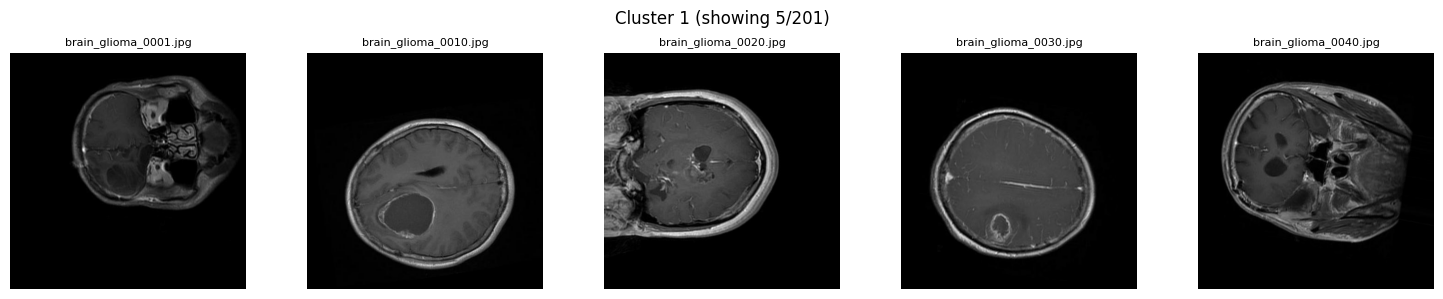


Cluster 2 (201)


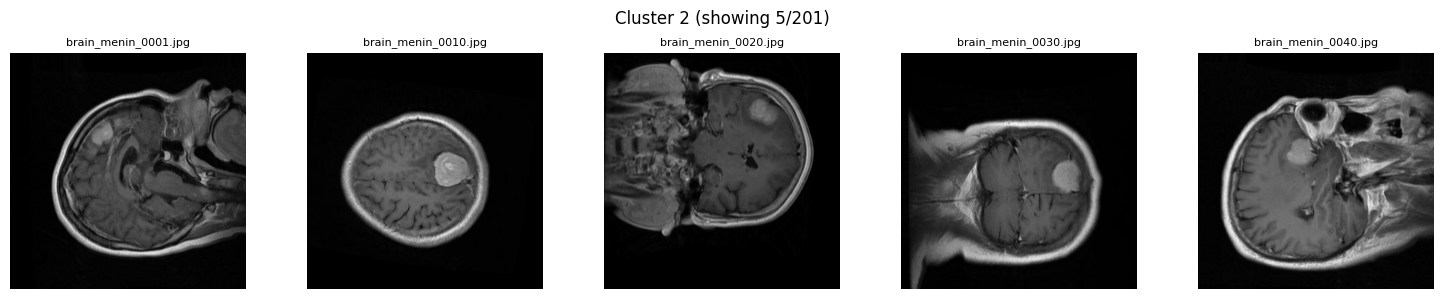


Cluster 3 (201)


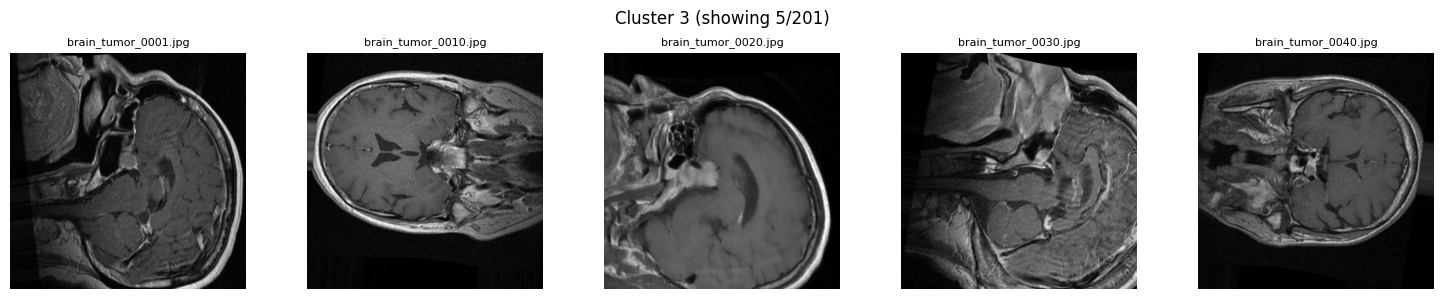

In [ ]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt

max_images = 5  # how many I want per cluster to display

for cluster_id in range(k):

    cluster_idxs = np.where(labels == cluster_id)[0] # finds all the cluster_idxs that belong in that cluster
    n_imgs = len(cluster_idxs)

    print(f"\nCluster {cluster_id + 1} ({n_imgs})")

    if n_imgs == 0:
        continue

    # limit to 10 images
    cluster_idxs = cluster_idxs[:max_images]
    n_show = len(cluster_idxs)

    cols = 5
    rows = math.ceil(n_show / cols)

    fig = plt.figure(figsize=(cols * 3, rows * 3))

    for i, idx in enumerate(cluster_idxs):
        uid = unique_ids[idx]

        sample_idx = np.where(np.array(image_ids) == uid)[0][0]

        cls, fname = file_names[sample_idx]

        img = image.load_img(
            os.path.join(base_path, cls, fname),
            target_size=(512, 512)
        )

        ax = fig.add_subplot(rows, cols, i + 1)
        ax.imshow(img)
        ax.axis("off")

        ax.set_title(fname, fontsize=8)

    fig.suptitle(f"Cluster {cluster_id + 1} (showing {n_show}/{n_imgs})")

    plt.tight_layout()

    plt.savefig(
        f"cluster_{cluster_id + 1}.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)